# Practical 09 — Support Vector Machine with Hyperparameter Tuning

## 1. Aim & Objectives

**Aim:** To implement a Support Vector Machine classifier and tune its hyperparameters using GridSearchCV.

**Objectives:**
1. Build a scaling + SVM pipeline on the heart-disease dataset.
2. Search for the best combination of `C`, `gamma` and `kernel` using 5-fold cross-validation.
3. Report the test accuracy and plot the effect of `C` along with the confusion matrix.

## 2. Complete Python Code


Shape of dataset : (303, 14)
target
1    165
0    138
Name: count, dtype: int64

Default SVM accuracy : 0.8197
C = 0.01  cross-validation accuracy : 0.5454
C = 0.1  cross-validation accuracy : 0.8226
C = 1  cross-validation accuracy : 0.802
C = 10  cross-validation accuracy : 0.7814
C = 100  cross-validation accuracy : 0.7771



Best parameters : {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV accuracy: 0.8393

Tuned SVM test accuracy : 0.7869

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



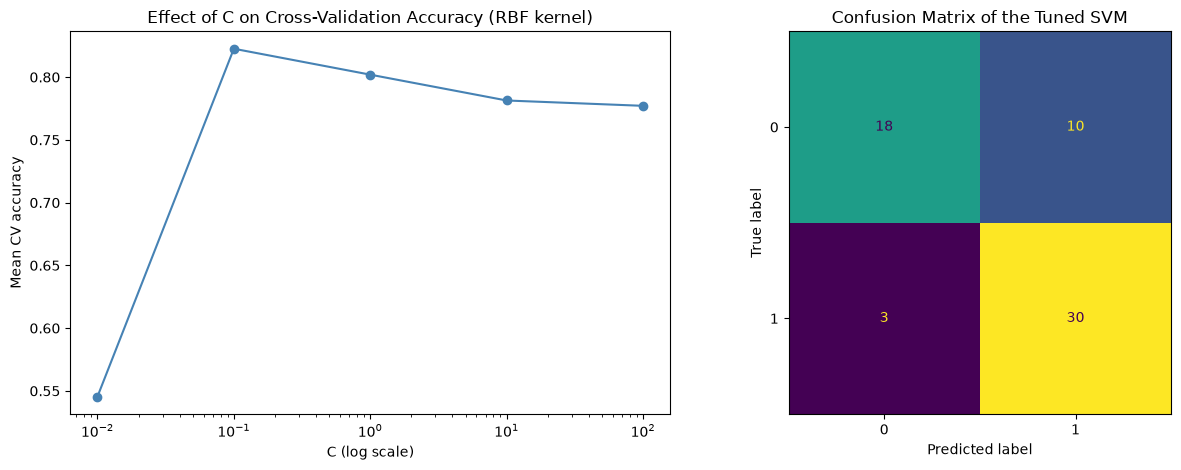

In [1]:
# Practical 09 - Support Vector Machine with Hyperparameter Tuning
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Step 1: Load the dataset
CSV = "data/heart_disease.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/09_SVM_Hyperparameter_Tuning/data/heart_disease.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print(df["target"].value_counts())

X = df.drop(columns="target")
y = df["target"]

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: A simple SVM with default settings
base_model = make_pipeline(StandardScaler(), SVC())
base_model.fit(X_train, y_train)
print("\nDefault SVM accuracy :", round(accuracy_score(y_test, base_model.predict(X_test)), 4))

# Step 4: See how the value of C changes the cross-validation score
C_values = [0.01, 0.1, 1, 10, 100]
cv_scores = []
for c in C_values:
    pipe = make_pipeline(StandardScaler(), SVC(C=c, kernel="rbf"))
    cv_scores.append(cross_val_score(pipe, X_train, y_train, cv=5).mean())
    print("C =", c, " cross-validation accuracy :", round(cv_scores[-1], 4))

# Step 5: Tune C, gamma and kernel together with GridSearchCV
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
    "svc__kernel": ["linear", "rbf"],
}
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC()), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\nBest parameters :", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

# Step 6: Evaluate the tuned model on the test data
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("\nTuned SVM test accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Step 7: Plot the effect of C and the confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(C_values, cv_scores, marker="o", color="steelblue")
ax[0].set_xscale("log")
ax[0].set_title("Effect of C on Cross-Validation Accuracy (RBF kernel)")
ax[0].set_xlabel("C (log scale)")
ax[0].set_ylabel("Mean CV accuracy")

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1], colorbar=False)
ax[1].set_title("Confusion Matrix of the Tuned SVM")

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.svm import SVC` — the Support Vector Classifier. It draws the boundary that keeps the largest possible margin between the two classes.
- `from sklearn.pipeline import make_pipeline` — joins the scaler and the model into one object, so scaling is always done correctly inside cross-validation.
- `from sklearn.model_selection import GridSearchCV, cross_val_score` — tools that try many settings and score them with cross-validation.
- `X = df.drop(columns="target")` — the 13 patient measurements; `y = df["target"]` — 1 means heart disease present, 0 means absent.
- `make_pipeline(StandardScaler(), SVC())` — first scales the features, then trains the SVM. SVM is distance-based, so scaling is compulsory.
- `cross_val_score(pipe, X_train, y_train, cv=5)` — splits the training data into 5 parts, trains on 4 and tests on 1, five times, and returns the five scores. `.mean()` gives their average.
- `C` — the penalty for a misclassified point. A small C allows more mistakes (wider margin, simpler model); a large C tries to classify every training point correctly (narrow margin, risk of overfitting).
- `gamma` — how far the influence of a single training point reaches in the RBF kernel. Large gamma means a very wiggly boundary.
- `kernel` — `"linear"` draws a straight boundary, `"rbf"` can draw a curved one.
- `param_grid` — the dictionary of values to try. The prefix `svc__` tells the pipeline that these settings belong to the SVC step.
- `GridSearchCV(..., cv=5)` — trains a model for **every** combination in the grid and keeps the one with the best average cross-validation score.
- `grid.best_params_` / `grid.best_score_` — the winning settings and their cross-validation accuracy.
- `grid.best_estimator_` — the pipeline already retrained on the full training set with those best settings.
- `accuracy_score(y_test, y_pred)` — the final honest score, measured on data never used during tuning.
- `ax[0].set_xscale("log")` — the C values 0.01 to 100 are spread over a wide range, so a log axis shows them evenly.
- `ConfusionMatrixDisplay.from_estimator(...)` — the confusion matrix of the tuned model.


## 4. Output & Graph Interpretation

The first graph shows that a very small C (0.01) gives poor accuracy because the model becomes too simple, the score peaks near C = 0.1, and it falls again for large C where the model starts overfitting — this is why C must be tuned and not guessed.

GridSearchCV selects the linear kernel with C = 1 and reaches about 0.84 cross-validation accuracy; the test accuracy is slightly lower (about 0.79) because the test set has only 61 patients, which reminds us that the best cross-validation setting is not a guarantee on new data.
